# How upset are customers, and what are they upset about?
### Distress and text analysis of credit card complaints

**Goal:** measure *how distressed* complainants are, find the words behind the anger, and see whether angrier complaints get different outcomes.

**Data:** CFPB Consumer Complaint Database (public, real complaints against banks), Jan-Feb 2026 extract.

**Design note:** every narrative here is a complaint, so almost everyone is unhappy. A positive/negative split would say nothing.
Instead we treat sentiment as **intensity of distress** (Calm/Factual -> Frustrated -> Angry/Distressed) and check it against manual labels.

**Steps:** Load -> Clean -> Distress score (VADER) -> Validate by hand -> Common words -> Compare groups -> Outcomes -> Export

> Setup once: `pip install pandas scikit-learn vaderSentiment matplotlib jupyter`
> Data: CFPB export saved as `data/Complaints_JanFeb2026.csv`.

In [1]:
# Step 0: tools we need.
# pandas = spreadsheets in Python; VADER = the "mood dictionary"; CountVectorizer = a word counter.
import os
import re
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option("display.max_colwidth", 120)
SEED = 42  # fixed seed so results are the same every run
os.makedirs("output", exist_ok=True)

## Step 1: Load the data and keep only what we need
One product (credit cards) and only complaints where the customer wrote a story. Focused data = a clearer story.

In [2]:
# The file is ~350 MB / 1 million rows, too big to load in one go on many laptops.
# So we read it in chunks of 50k rows and keep only credit card complaints that have a written story.
NARRATIVE = "Consumer complaint narrative"
pieces = []
total_rows = 0
NEEDED = ["Date received", "Product", "Sub-product", "Issue", "Sub-issue", NARRATIVE, "Company", "State",
          "Company response to consumer", "Timely response?", "Complaint ID"]   # skip the columns we don't use to save memory
for chunk in pd.read_csv("data/Complaints_JanFeb2026.csv", chunksize=50_000, dtype=str, usecols=NEEDED):
    total_rows += len(chunk)
    keep = chunk["Product"].str.contains("credit card", case=False, na=False) & chunk[NARRATIVE].notna()
    pieces.append(chunk[keep])
raw = pd.concat(pieces, ignore_index=True)
print("Rows in file:", total_rows)
print("Credit card complaints with a narrative:", len(raw))
print(raw.columns.tolist())

Rows in file: 1038383
Credit card complaints with a narrative: 5771
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company', 'State', 'Company response to consumer', 'Timely response?', 'Complaint ID']


In [3]:
df = raw.sample(n=min(15000, len(raw)), random_state=SEED).copy()   # cap at 15k so it runs fast
df["Date received"] = pd.to_datetime(df["Date received"])
# the data covers only Jan-Feb 2026, so we trend by week (a monthly chart would have just 2 points)
df["week"] = df["Date received"].dt.to_period("W").dt.start_time
print("Rows we will analyse:", len(df))
df[["Date received", "Issue", NARRATIVE]].head()

Rows we will analyse: 5771


,Date received,Issue,Consumer complaint narrative
426,2026-02-23,Fees or interest,am filing a complaint against Synchrony Bank and a merchant named XXXX XXXX for unfair and deceptive billing practic...
2226,2026-01-13,Problem with a purchase shown on your statement,My wallet was stolen from my apartment complex parking lot. The apartment management confirmed the theft through sec...
5107,2026-02-09,Fees or interest,"Hello, I am formally disputing multiple late payment fees that were charged to my account within a very short time f..."
2145,2026-01-13,Problem with fraud alerts or security freezes,"I copy my ssn, social security and drive license. \nI wrote a letter explaining why I would like to freeze my credit..."
4868,2026-02-05,Fees or interest,"I applied for this credit card and never received the card and never activated it. Despite this, I was charged an an..."


## Step 2: Clean the text
Computers treat "Fee", "fee" and "FEE!!" as different words. Cleaning makes them the same.
CFPB hides personal details as `XXXX` and amounts like `{$25.00}`, so we remove those too.

VADER works best on the *original* text (it reads capitals and "!!!" as extra emotion),
so we clean lightly for VADER and heavily for word counting.

In [4]:
def light_clean(text):
    """For VADER: only remove the hidden-info placeholders."""
    text = re.sub(r"X{2,}", " ", text)
    text = re.sub(r"\{\$[\d.,]+\}", " ", text)
    return text

def clean_text(text):
    """For word counting: lowercase, letters only."""
    text = text.lower()                          # FEE -> fee
    text = re.sub(r"x{2,}", " ", text)           # remove XXXX
    text = re.sub(r"\{\$[\d.,]+\}", " ", text)   # remove {$25.00}
    text = re.sub(r"[^a-z\s]", " ", text)        # keep letters only
    text = re.sub(r"\s+", " ", text).strip()     # tidy spaces
    return text

df["clean"] = df[NARRATIVE].apply(clean_text)
df[[NARRATIVE, "clean"]].head(3)

,Consumer complaint narrative,clean
426,am filing a complaint against Synchrony Bank and a merchant named XXXX XXXX for unfair and deceptive billing practic...,am filing a complaint against synchrony bank and a merchant named for unfair and deceptive billing practices imprope...
2226,My wallet was stolen from my apartment complex parking lot. The apartment management confirmed the theft through sec...,my wallet was stolen from my apartment complex parking lot the apartment management confirmed the theft through secu...
5107,"Hello, I am formally disputing multiple late payment fees that were charged to my account within a very short time f...",hello i am formally disputing multiple late payment fees that were charged to my account within a very short time fr...


## Step 3: Distress score with VADER
VADER is a dictionary where every word has a mood score ("terrible" = very negative, "helpful" = positive).
It adds up the scores and returns a **compound score from -1 (very distressed) to +1 (calm / polite)**.

Because everyone here is complaining, we read the score as **how strongly the customer expresses distress**, in three levels:

| Level | Meaning | Default rule |
|---|---|---|
| Calm/Factual | states the problem in a measured, polite or neutral tone | score > -0.05 |
| Frustrated | clearly unhappy, some strong wording | -0.75 < score <= -0.05 |
| Angry/Distressed | very strong negative language | score <= -0.75 |

The cut-offs are a starting point. After Step 4 you can tune them to match your own judgement.

In [5]:
analyzer = SentimentIntensityAnalyzer()
df["sentiment"] = df[NARRATIVE].apply(lambda t: analyzer.polarity_scores(light_clean(t))["compound"])

ANGRY_CUTOFF = -0.75   # at or below this = Angry/Distressed
CALM_CUTOFF = -0.05    # above this = Calm/Factual

def distress_level(score):
    if score <= ANGRY_CUTOFF:
        return "Angry/Distressed"
    if score <= CALM_CUTOFF:
        return "Frustrated"
    return "Calm/Factual"

df["distress_level"] = df["sentiment"].apply(distress_level)
LEVELS = ["Calm/Factual", "Frustrated", "Angry/Distressed"]
print(df["distress_level"].value_counts(normalize=True).reindex(LEVELS).round(3))

distress_level
Calm/Factual        0.460
Frustrated          0.198
Angry/Distressed    0.341
Name: proportion, dtype: float64


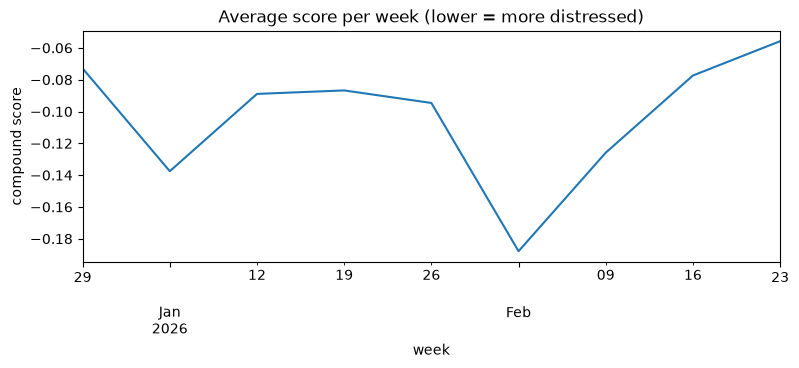

In [6]:
# How does distress change over time?
df.groupby("week")["sentiment"].mean().plot(figsize=(9, 3), title="Average score per week (lower = more distressed)")
plt.ylabel("compound score")
plt.show()

## Step 4: Check the tool's work (manual validation)
A tool is only useful if it's right. Take 60 complaints, **judge the level of distress yourself**, then compare with VADER.

1. Run the next cell. It creates `output/validation_sample.csv`.
2. Open it in Excel and fill the empty `my_label` column with exactly one of:
   `Calm/Factual`, `Frustrated` or `Angry/Distressed`. Judge the customer's **tone**, not how bad the events were.
   - *Calm/Factual*: describes the problem in a measured way, no strong emotion.
   - *Frustrated*: clearly unhappy, mentions repeated attempts, unfairness, wasted time.
   - *Angry/Distressed*: very strong language, accusations, threats, financial or emotional harm.
3. Save as CSV (same name), then run the cell after that.

**Tip:** if agreement is low, look at *where* it disagrees (the table shows this) and adjust `ANGRY_CUTOFF` / `CALM_CUTOFF` in Step 3.

In [7]:
sample = df.sample(60, random_state=SEED)[["Complaint ID", NARRATIVE, "sentiment", "distress_level"]].copy()
sample["my_label"] = ""
sample.to_csv("output/validation_sample.csv", index=False)
print("Saved output/validation_sample.csv - now label it by hand.")

Saved output/validation_sample.csv - now label it by hand.


In [19]:
checked = pd.read_csv("output/validation_sample.csv")
checked = checked[checked["my_label"].notna() & (checked["my_label"] != "")]

agreement = (checked["my_label"] == checked["distress_level"]).mean()
# "within one level" is a fairer test: Calm vs Frustrated is a smaller miss than Calm vs Angry
rank = {name: i for i, name in enumerate(LEVELS)}
within_one = ((checked["my_label"].map(rank) - checked["distress_level"].map(rank)).abs() <= 1).mean()
print(f"Exact agreement with me: {agreement:.0%} of {len(checked)} complaints")
print(f"Within one level:        {within_one:.0%}")
print(pd.crosstab(checked["my_label"], checked["distress_level"], rownames=["My label"], colnames=["VADER level"]))

# Write in your README: where does VADER go wrong? (polite-but-angry? sarcasm? stories of bad events scored as angry?)

Exact agreement with me: 80% of 60 complaints
Within one level:        93%
VADER level       Angry/Distressed  Calm/Factual  Frustrated
My label                                                    
Angry/Distressed                 9             2           3
Calm/Factual                     2            27           1
Frustrated                       3             1          12


## Step 5: What words are behind the anger?
We count the most common **2-word phrases** (they say more than single words: "late fee" vs "late").
Stop words (the, and, is...) and bank names are ignored so real problem words stand out.
Then we compare Angry/Distressed complaints with Calm/Factual ones and show the phrases much more common in the angry group.

In [9]:
# Extra words to ignore: they appear in almost every complaint or are just bank names, so they hide the real story.
EXTRA_STOP = ["credit", "card", "bank", "america", "american", "express", "wells", "fargo", "synchrony", "goldman",
              "sachs", "capital", "chase", "citi", "citibank", "discover", "barclays", "account", "complaint",
              "filing", "regarding", "company"]
STOP = list(ENGLISH_STOP_WORDS.union(EXTRA_STOP))

def top_phrases(texts):
    vec = CountVectorizer(stop_words=STOP, ngram_range=(2, 2), min_df=10)
    counts = vec.fit_transform(texts)
    freq = pd.Series(counts.sum(axis=0).A1, index=vec.get_feature_names_out())
    return (freq / len(texts)).sort_values(ascending=False)   # share of complaints containing the phrase

angry = top_phrases(df.loc[df["distress_level"] == "Angry/Distressed", "clean"])
calm = top_phrases(df.loc[df["distress_level"] == "Calm/Factual", "clean"])

print("Top phrases in ANGRY/DISTRESSED complaints:\n", angry.head(15).round(3), "\n")
print("Top phrases in CALM/FACTUAL complaints:\n", calm.head(15).round(3))

Top phrases in ANGRY/DISTRESSED complaints:
 customer service            0.186
fair billing                0.149
billing act                 0.147
billing error               0.139
denied dispute              0.131
billing dispute             0.124
identity theft              0.123
multiple times              0.122
fraudulent charges          0.119
unauthorized charges        0.119
reasonable investigation    0.118
good faith                  0.101
did authorize               0.101
disputed charge             0.099
police report               0.098
dtype: float64 

Top phrases in CALM/FACTUAL complaints:
 customer service        0.208
good faith              0.105
late fees               0.101
late payment            0.096
late fee                0.093
payment history         0.092
annual fee              0.075
multiple times          0.070
best buy                0.070
written confirmation    0.069
good standing           0.063
balance transfer        0.061
identity theft          0.0

In [10]:
# Phrases that stand out in angry complaints (much more common than in calm ones)
compare = pd.DataFrame({"angry": angry, "calm": calm}).fillna(0.0001)
compare["ratio"] = compare["angry"] / compare["calm"]
compare = compare[compare["angry"] > 0.005].sort_values("ratio", ascending=False)
compare.head(15).round(3)

,angry,calm,ratio
dispute process,0.056,0.0,563.452
closed dispute,0.051,0.0,512.690
services rendered,0.051,0.0,507.614
reported fraud,0.044,0.0,436.548
fraud dispute,0.041,0.0,411.168
disputed transactions,0.038,0.0,380.711
dispute closed,0.037,0.0,370.558
dispute handling,0.036,0.0,360.406
non delivery,0.036,0.0,360.406
fraudulent transactions,0.036,0.0,355.330


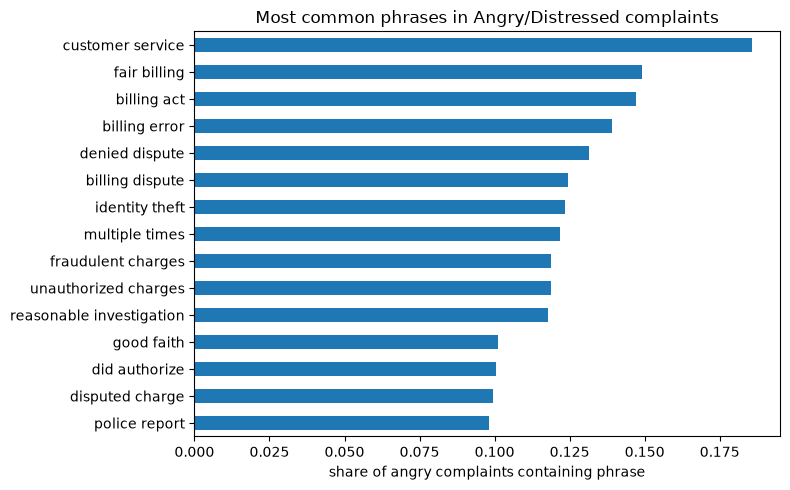

In [11]:
angry.head(15).sort_values().plot.barh(figsize=(8, 5), title="Most common phrases in Angry/Distressed complaints")
plt.xlabel("share of angry complaints containing phrase")
plt.tight_layout()
plt.show()

## Step 6: Compare groups - who is most distressed?
For each **issue** and **company**: average score and the share of complaints that are Angry/Distressed.
This is where the recommendations come from.
(Every complaint in this extract came through the web, so a channel comparison would be meaningless.)

In [12]:
df["is_angry"] = (df["distress_level"] == "Angry/Distressed")

by_issue = df.groupby("Issue").agg(
    complaints=("Complaint ID", "count"),
    avg_score=("sentiment", "mean"),
    pct_angry=("is_angry", "mean"),
).query("complaints >= 100").sort_values("pct_angry", ascending=False)
by_issue.round(3)

,complaints,avg_score,pct_angry
Issue,,,
Problem with a purchase shown on your statement,1983,-0.525,0.594
Trouble using your card,247,-0.167,0.352
Problem when making payments,304,-0.015,0.253
"Other features, terms, or problems",711,0.090,0.249
Incorrect information on your report,248,0.059,0.222
Closing your account,416,0.113,0.216
Problem with a company's investigation into an existing problem,132,-0.020,0.212
Getting a credit card,575,0.117,0.162
Fees or interest,731,0.250,0.161


In [13]:
by_company = df.groupby("Company").agg(
    complaints=("Complaint ID", "count"),
    avg_score=("sentiment", "mean"),
    pct_angry=("is_angry", "mean"),
).query("complaints >= 100").sort_values("pct_angry", ascending=False)
by_company.round(3)

,complaints,avg_score,pct_angry
Company,,,
GOLDMAN SACHS BANK USA,216,-0.414,0.528
DISCOVER BANK,227,-0.345,0.467
"BANK OF AMERICA, NATIONAL ASSOCIATION",335,-0.223,0.448
AMERICAN EXPRESS COMPANY,330,-0.131,0.382
CAPITAL ONE FINANCIAL CORPORATION,701,-0.142,0.371
BARCLAYS BANK DELAWARE,158,-0.177,0.361
JPMORGAN CHASE & CO.,435,-0.061,0.356
"CITIBANK, N.A.",710,-0.078,0.324
WELLS FARGO & COMPANY,201,-0.071,0.318


In [14]:
# A simple "priority" score: big AND angry issues first (volume share x share angry)
by_issue["volume_share"] = by_issue["complaints"] / by_issue["complaints"].sum()
by_issue["priority"] = (by_issue["volume_share"] * by_issue["pct_angry"]).round(4)
by_issue.sort_values("priority", ascending=False).head(10).round(3)

,complaints,avg_score,pct_angry,volume_share,priority
Issue,,,,,
Problem with a purchase shown on your statement,1983,-0.525,0.594,0.351,0.209
"Other features, terms, or problems",711,0.090,0.249,0.126,0.031
Fees or interest,731,0.250,0.161,0.130,0.021
Getting a credit card,575,0.117,0.162,0.102,0.016
Closing your account,416,0.113,0.216,0.074,0.016
Trouble using your card,247,-0.167,0.352,0.044,0.015
Problem when making payments,304,-0.015,0.253,0.054,0.014
Incorrect information on your report,248,0.059,0.222,0.044,0.010
"Advertising and marketing, including promotional offers",295,0.430,0.112,0.052,0.006


## Step 7: Do angrier complaints get different outcomes?
`Company response to consumer` tells us how the complaint ended. We group it into:
**Relief** (monetary or non-monetary) vs **Explanation only** (closed with explanation, i.e. no relief).
If distressed customers are no more likely to get relief, that is a service-recovery gap worth flagging.

outcome           Explanation only  Other  Relief
distress_level                                   
Calm/Factual                  74.7    0.0    25.3
Frustrated                    72.6    0.2    27.2
Angry/Distressed              73.1    0.1    26.8


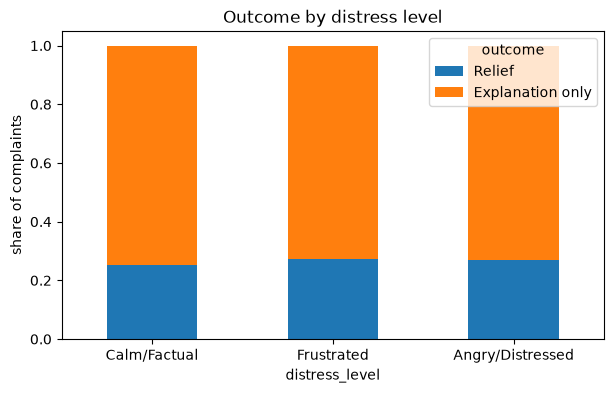

In [15]:
df["outcome"] = df["Company response to consumer"].map({
    "Closed with monetary relief": "Relief",
    "Closed with non-monetary relief": "Relief",
    "Closed with explanation": "Explanation only",
}).fillna("Other")

outcome = pd.crosstab(df["distress_level"], df["outcome"], normalize="index").reindex(LEVELS)
print((outcome * 100).round(1))
outcome[["Relief", "Explanation only"]].plot.bar(stacked=True, figsize=(7, 4), title="Outcome by distress level")
plt.ylabel("share of complaints")
plt.xticks(rotation=0)
plt.show()

In [16]:
# Same view by issue: where do customers get relief least often?
relief_by_issue = df.groupby("Issue").agg(
    complaints=("Complaint ID", "count"),
    pct_relief=("outcome", lambda s: (s == "Relief").mean()),
    pct_angry=("is_angry", "mean"),
).query("complaints >= 100").sort_values("pct_relief")
relief_by_issue.round(3)

,complaints,pct_relief,pct_angry
Issue,,,
Trouble using your card,247,0.109,0.352
Problem with a company's investigation into an existing problem,132,0.152,0.212
Closing your account,416,0.178,0.216
Incorrect information on your report,248,0.230,0.222
"Other features, terms, or problems",711,0.250,0.249
"Advertising and marketing, including promotional offers",295,0.258,0.112
Getting a credit card,575,0.268,0.162
Problem when making payments,304,0.286,0.253
Problem with a purchase shown on your statement,1983,0.287,0.594


## Step 8: Export for SQL and Power BI

In [17]:
out_cols = ["Complaint ID", "Date received", "week", "Product", "Sub-product", "Issue", "Sub-issue", "Company", "State",
            "Company response to consumer", "Timely response?", "outcome",
            "sentiment", "distress_level", NARRATIVE]
export = df[out_cols].rename(columns={NARRATIVE: "narrative"})
export.to_csv("output/complaints_enriched.csv", index=False)
angry.head(30).rename("share_of_angry_complaints").to_csv("output/angry_phrases.csv")

with sqlite3.connect("output/complaints.db") as con:
    export.to_sql("complaints", con, if_exists="replace", index=False)
print("Saved: output/complaints_enriched.csv, output/angry_phrases.csv, output/complaints.db")

Saved: output/complaints_enriched.csv, output/angry_phrases.csv, output/complaints.db


## Step 9: Your findings (fill in after running)
1. **Overall distress:** ...% of complaints are Angry/Distressed, ...% Frustrated, ...% Calm/Factual.
2. **Most distressing issues:** ...
3. **Words behind the anger:** ...
4. **Company / time differences:** ...
5. **Outcomes:** do angrier complaints get relief more or less often? ...
6. **Recommendations (2-3):** ...
7. **Limitations:** VADER measures wording, not true emotion (misses sarcasm, polite anger, and can score a bad story as "angry"); exact agreement with my manual labels was ...% (...% within one level); sample of ~5.8k complaints from Jan-Feb 2026 only.